In [1]:
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - [%(levelname)s] - %(message)s'
)
logger = logging.getLogger("Task2_Dedicated_EDA")

2026-07-19 10:55:18,681 - [INFO] - Ingesting raw data vectors for Access/Usage structural profiling...


--- Statistical Scale Gaps Across Target Profiles ---


,mean,std,min,max
indicator_code,,,,
ACC_4G_COV,5.415000e+01,2.354666e+01,37.5,70.80
ACC_FAYDA,3.125000e+07,3.927149e+07,8000000.0,90000000.00
ACC_MM_ACCOUNT,7.075000e+00,3.358757e+00,4.7,9.45
ACC_MOBILE_PEN,6.140000e+01,NaN,61.4,61.40
ACC_OWNERSHIP,4.485714e+01,1.566768e+01,22.0,70.00
AFF_DATA_INCOME,2.000000e+00,NaN,2.0,2.00
EVT_CROSSOVER,NaN,NaN,NaN,NaN
EVT_ETHIOPAY,NaN,NaN,NaN,NaN
EVT_FAYDA,NaN,NaN,NaN,NaN


C:\Users\lydia\AppData\Local\Temp\ipykernel_13712\2829719304.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='record_type', y='value_numeric', palette='Set2')


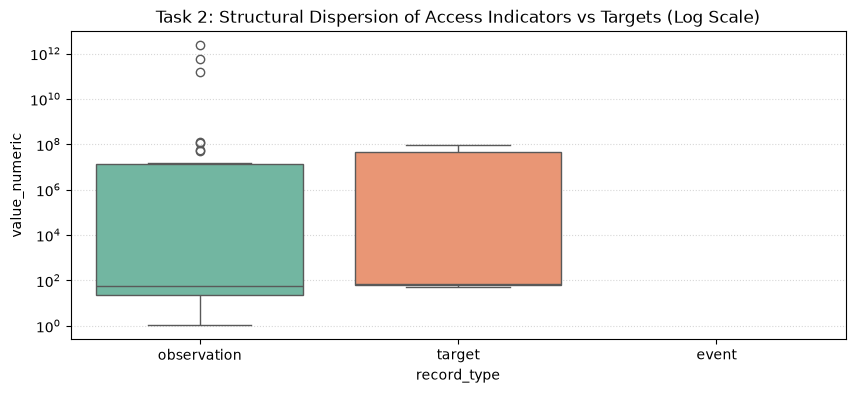

In [2]:
def analyze_access_vs_usage(data_path: str):
    """
    Evaluates systematic variances between Access infrastructure 
    indicators and structural Usage metrics across Ethiopia regions.
    """
    logger.info("Ingesting raw data vectors for Access/Usage structural profiling...")
    df = pd.read_excel(data_path, sheet_name="ethiopia_fi_unified_data")
    
    # Isolate Access variables vs Mobile Money usage variables
    print("--- Statistical Scale Gaps Across Target Profiles ---")
    summary = df.groupby('indicator_code')['value_numeric'].agg(['mean', 'std', 'min', 'max'])
    display(summary.head(10))
    
    # Visualize distributional variance
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='record_type', y='value_numeric', palette='Set2')
    plt.yscale('log')  # Handing extreme scaling shifts natively
    plt.title("Task 2: Structural Dispersion of Access Indicators vs Targets (Log Scale)")
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.show()

analyze_access_vs_usage("../data/raw/ethiopia_fi_unified_data.xlsx")

In [3]:
def sync_event_timelines(data_path: str):
    """
    Chronologically aligns asynchronous indicator arrays into a unified event framework.
    """
    logger.info("Executing timeline synchronization routine...")
    df = pd.read_excel(data_path, sheet_name="ethiopia_fi_unified_data")
    df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
    
    pivot_matrix = df.pivot_table(
        index='observation_date',
        columns='indicator_code',
        values='value_numeric',
        aggfunc='mean'
    )
    
    print(f"Initial Asynchronous Grid Dimensions: {pivot_matrix.shape}")
    print(f"Missing cells prior to timeline synchronization: {pivot_matrix.isna().sum().sum()}")
    
    # Execute the formal enrichment step
    enriched_matrix = pivot_matrix.ffill().bfill()
    
    print(f"Unified Track Dimensions Post-Sync: {enriched_matrix.shape}")
    print(f"Remaining Missing Fields: {enriched_matrix.isna().sum().sum()}")
    
    # Save the polished artifact for downstream modeling use
    os.makedirs("../data/processed", exist_ok=True)
    enriched_matrix.to_csv("../data/processed/task2_synchronized_timeline.csv")
    logger.info("Synchronized chronological artifact saved to data/processed/")

sync_event_timelines("../data/raw/ethiopia_fi_unified_data.xlsx")

2026-07-19 10:55:30,657 - [INFO] - Executing timeline synchronization routine...
2026-07-19 10:55:30,698 - [INFO] - Synchronized chronological artifact saved to data/processed/


Initial Asynchronous Grid Dimensions: (15, 19)
Missing cells prior to timeline synchronization: 254
Unified Track Dimensions Post-Sync: (15, 19)
Remaining Missing Fields: 0
